This is a jax-base implementation of the [TransformerPayne](https://iopscience.iop.org/article/10.3847/1538-4357/ad9b99) to test feasibility for the phoenix model case.

In [1]:
import time
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np

from matplotlib import pyplot as plt

from astropy import units as u
from astropy.io import fits   

from astropy import visualization as viz
viz.quantity_support()

from jwst import datamodels

from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
import equinox as eqx
import optax
rkey = jax.random.PRNGKey(42)
jax.devices()

[CudaDevice(id=0)]

# TransformerPayne architecture and timing tests

In [2]:
class TPWLEmbedding(eqx.Module):
    omegas: jnp.ndarray

    def __init__(self, omegas):
        self.omegas = jnp.array(omegas, copy=False).ravel()
        
    @classmethod
    def from_tp_paper(cls, d):
        ps = jnp.linspace(1e-6, 10, d)
        return cls(2*jnp.pi/ps)

    @property
    def d(self):
        return self.omegas.shape[0]

    def __call__(self, x):
        return jnp.sin(self.omegas*x)


In [3]:
class TPTransformerBlock(eqx.Module):
    ff_layer: eqx.nn.MLP
    mha: eqx.nn.MultiheadAttention
    lnorm1: eqx.nn.LayerNorm
    lnorm2: eqx.nn.LayerNorm
    
    def __init__(self, num_heads, d, ff_activation, rkey):
        rkey1, rkey2 = jax.random.split(rkey, 2)

        self.mha = eqx.nn.MultiheadAttention(num_heads, d, key=rkey1)
        self.lnorm1 = eqx.nn.LayerNorm(d)
        self.ff_layer = eqx.nn.MLP(d, d, d, 2, activation=ff_activation, key=rkey2)
        self.lnorm2 = eqx.nn.LayerNorm(d)
        
    def __call__(self, q, k, v):
        """
        q,k,v should all be 2d, trailing dimension d

        returns (mhaout, ffout, xout) all length d 
        """
        mhaoutres = self.mha(q, k, v)
        mhaout = (mhaoutres + q).ravel()
        ffin = self.lnorm1(mhaout)
        ffoutres = self.ff_layer(ffin)
        ffout = ffoutres + mhaout
        xout = self.lnorm2(ffout)
        return mhaout, ffout, xout

In [4]:
class TransformerPayne(eqx.Module):
    wl_embedding: eqx.Module
    emb_mlp: eqx.nn.MLP
    tblocks: list
    head_norm: eqx.nn.LayerNorm
    head_mlp: eqx.nn.MLP

    def __init__(self, n_stellar_params, 
                 d=256,
                 t=16,
                 n_tblocks=1, 
                 num_heads=8,
                 nlayers_emb_mlp=2, 
                 nlayers_head_mlp=2,
                 embedded_omegas=None,
                 emb_activation=jax.nn.gelu,
                 head_activation=jax.nn.gelu,
                 tblock_activation=jax.nn.gelu,
                 rkey=None):
        if rkey is None:
            rkey = jax.random.key(time.time_ns())

        rkey1, rkey2, rkey3 = jax.random.split(rkey, 3)
                 
        if embedded_omegas is None:
            self.wl_embedding = TPWLEmbedding.from_tp_paper(d)
        else:
            self.wl_embedding = TPWLEmbedding(embedded_omegas)
        self.emb_mlp = eqx.nn.MLP(n_stellar_params, d*t, d*t, nlayers_emb_mlp, activation=emb_activation, key=rkey1)
        
        self.tblocks = [TPTransformerBlock(num_heads, d, tblock_activation, rkey=rkey2) for _ in range(n_tblocks)]  # Placeholder for actual transformer blocks
    
        self.head_norm = eqx.nn.LayerNorm(d, use_bias=False, use_weight=False)
        self.head_mlp = eqx.nn.MLP(d, 1, d, nlayers_head_mlp, activation=head_activation, key=rkey3)

    def __call__(self, wl, stellar_params):
        wemb = self.wl_embedding(wl).ravel() # length d
        pemb = self.emb_mlp(stellar_params) # length td

        q = wemb # length d
        kv = pemb.reshape(-1, wemb.shape[-1]) # t x d
        xskip = q # length d
        for tblock in self.tblocks:
            mhaout, ffout, q = tblock(q.reshape(1, -1), kv, kv) # all outputs length d
            xskip = xskip + mhaout + ffout

        return self.head_mlp(self.head_norm(xskip + q))


testtp = TransformerPayne(3)
print(sum(x.size for x in jax.tree.leaves(testtp) if eqx.is_array(x)) * 1e-6, 'Mparams')

wls = jnp.array([1.])
params = jnp.array([0.5, 0.5, 0.5])

# un-jitted version for debugging
testtp(wls, params)

34.171648999999995 Mparams


Array([-0.00523308], dtype=float32)

Now do some timing tests for evaluating a single spectrum 

In [5]:
testtp = TransformerPayne(3)

wls = jnp.arange(8900) + 1
params = jnp.array([0.5, 0.5, 0.5])
# measure JAX device transfer time
%time wls = jax.device_put(wls).block_until_ready()
%time params = jax.device_put(params).block_until_ready()

testtp_jit = jax.jit(jax.vmap(testtp, in_axes=(0, None)))
%time testtp_jit(wls, params).block_until_ready()  # measure JAX compilation time
%timeit testtp_jit(wls, params).block_until_ready()  # measure JAX runtime


CPU times: user 447 μs, sys: 36 μs, total: 483 μs
Wall time: 487 μs
CPU times: user 39 μs, sys: 0 ns, total: 39 μs
Wall time: 39.6 μs
CPU times: user 10.9 s, sys: 495 ms, total: 11.4 s
Wall time: 3.31 s
824 μs ± 8.24 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Well that's excellent news, under the 1ms evaluation time we need so there's some overhead for fiddling with stuff.  Worth trying to train.

In [6]:
wls = jnp.arange(8900) + 1
params = jnp.repeat(params[..., None], wls.shape[0], axis=-1).T
# measure JAX device transfer time
%time wls = jax.device_put(wls).block_until_ready()
%time params = jax.device_put(params).block_until_ready()

testtp_jit = jax.jit(jax.vmap(testtp))
%time testtp_jit(wls, params).block_until_ready()  # measure JAX compilation time
%timeit testtp_jit(wls, params).block_until_ready()  # measure JAX runtime


CPU times: user 77 μs, sys: 5 μs, total: 82 μs
Wall time: 84.9 μs
CPU times: user 40 μs, sys: 3 μs, total: 43 μs
Wall time: 42.9 μs


E0827 17:21:31.709457  201109 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


CPU times: user 15.7 s, sys: 459 ms, total: 16.2 s
Wall time: 4.09 s
20.4 ms ± 176 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


It's a *lot* slower without static stellar pops apparently? Has implications for training approaches

What about with more blocks?

In [7]:
testtp = TransformerPayne(3, n_tblocks=16)

wls = jnp.arange(8900) + 1
params = jnp.array([0.5, 0.5, 0.5])
# measure JAX device transfer time
%time wls = jax.device_put(wls).block_until_ready()
%time params = jax.device_put(params).block_until_ready()

testtp_jit = jax.jit(jax.vmap(testtp, in_axes=(0, None)))
%time testtp_jit(wls, params).block_until_ready()  # measure JAX compilation time
%timeit testtp_jit(wls, params).block_until_ready()  # measure JAX runtime


CPU times: user 56 μs, sys: 3 μs, total: 59 μs
Wall time: 61.5 μs
CPU times: user 30 μs, sys: 2 μs, total: 32 μs
Wall time: 34.6 μs
CPU times: user 22.7 s, sys: 421 ms, total: 23.1 s
Wall time: 4.82 s
7.72 ms ± 72.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


# Load Training Data

See [fast_phoenix_many.ipynb](fast_phoenix_many.ipynb) for tests on this.

In [8]:
phoenix_path = Path('../phoenix/fullgrid')

allspec = list(phoenix_path.glob('*.fits'))
wavepaths = [path for path in allspec if 'WAVE' in path.name]
assert len(wavepaths) == 1

with fits.open(wavepaths[0]) as f:
    wavehdu = f[0]
    ph_wave = wavehdu.data << u.Unit(wavehdu.header['UNIT'])


allspec = [path for path in allspec if 'WAVE' not in path.name]
len(allspec)

7559

In [9]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))

dm0 = datamodels.open(n6791fits[0])

slit = dm0.slits[49]
swcs = slit.meta.wcs

assert slit.source_name == '2609_21'

y, x = np.indices(slit.data.shape)
sky, spec = swcs.pixel_to_world(x, y)
densespec = np.linspace(np.nanmin(spec), np.nanmax(spec), x.shape[-1]*3)

In [10]:
class PhoenixResampler:
    def __init__(self, target_spacing, ph_wave, densespec):
        self.target_spacing = target_spacing
        msk = (densespec[0] < ph_wave) & (ph_wave < densespec[-1])
        self.resample_factor = int(round(target_spacing/np.max(np.diff(ph_wave[msk].to(u.angstrom)))))
        self.resample_msk = (densespec[0] < ph_wave) & (ph_wave < (densespec[-1]+target_spacing))
        self.cutoff_len = int(np.sum(self.resample_msk)/self.resample_factor)*self.resample_factor
        self.wave = self.subsample_data(ph_wave)

    def subsample_data(self, data):
        diced = data[self.resample_msk][:self.cutoff_len].reshape(-1, self.resample_factor)
        res = diced.mean(axis=1) 
        if hasattr(data, 'unit'):
            res = res << data.unit
        return res

phoenix_resampler = PhoenixResampler(0.5*u.angstrom, ph_wave, densespec)
resampled_wave = phoenix_resampler.wave
resampled_wave.shape

(8945,)

In [11]:
resampled_models = []
metas = defaultdict(list)
for path in tqdm(allspec):
    with fits.open(path) as f:
        resampled_models.append(phoenix_resampler.subsample_data(f[0].data))
        for key in ['PHXTEFF', 'PHXLOGG', 'PHXM_H', 'PHXALPHA']:
            metas[key].append(f[0].header[key])

stellar_models = jnp.array(resampled_models, dtype=jnp.float32)
stellar_metas = dict(metas)

assert len(set(stellar_metas['PHXALPHA'])) == 1 # only alpha/fe = 0 for this dataset

assert len(next(iter(metas.values()))) == stellar_models.shape[0]
stellar_models.shape

  0%|          | 0/7559 [00:00<?, ?it/s]

(7559, 8945)

In [12]:
stellar_parameter_names= ['PHXTEFF', 'PHXLOGG', 'PHXM_H']
stellar_parameter_arrs = jnp.array([stellar_metas[k] for k in stellar_parameter_names]).T
stellar_parameter_arrs.shape

(7559, 3)

Plot a few random ones as a sanity check

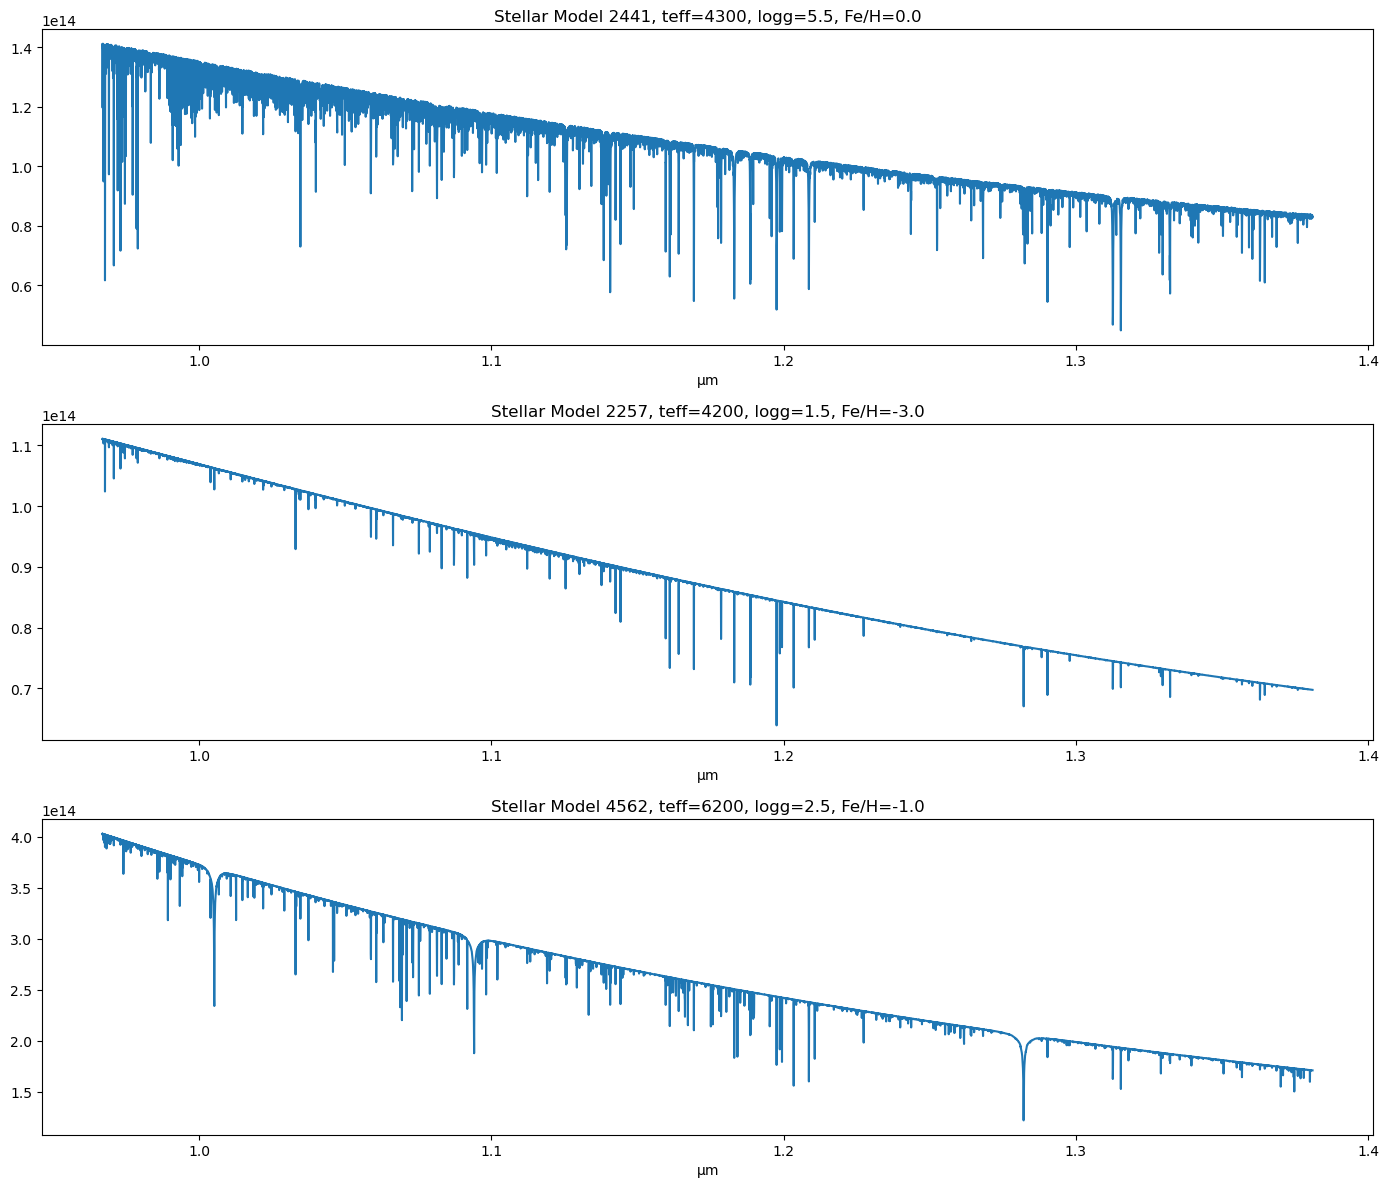

In [13]:
fig, axs = plt.subplots(3, 1, figsize=(14, 4*3))

for ax, i in zip(axs.ravel(), np.random.choice(len(stellar_models), 3, replace=False)):
    ax.plot(resampled_wave.to(u.micron), stellar_models[i])
    ax.set_title(f'Stellar Model {i}, teff={stellar_parameter_arrs[i,0]:.0f}, logg={stellar_parameter_arrs[i,1]}, Fe/H={stellar_parameter_arrs[i,2]}')
fig.tight_layout()

Also lets identify a model for examination purposes thats vaguely sun-like

In [14]:
sunlike_idx = jnp.where((stellar_parameter_arrs[:, 0] == 5800)&(stellar_parameter_arrs[:, 1] == 4.5)&(stellar_parameter_arrs[:, 2] == 0))[0][0]
sunlike_idx

Array(4168, dtype=int32)

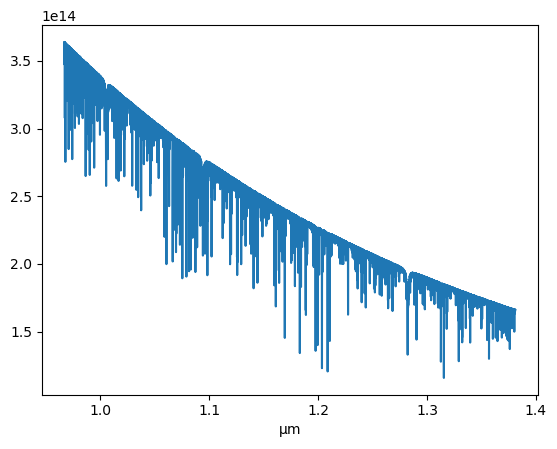

In [15]:
plt.plot(resampled_wave.to(u.micron), stellar_models[sunlike_idx])

## Data Renormalization/Reformatting

Now we renormalize the spectral data and stellar parameters to be in the neighborhood of 0-1. 

We do not alter the wavelengths because they are already scaled by the positional encoding omegas.

For the stellar models the y axis is arbitrarily scaled anyway so we just match the medians (this might be a thing to vary to get better fitting outcomes)

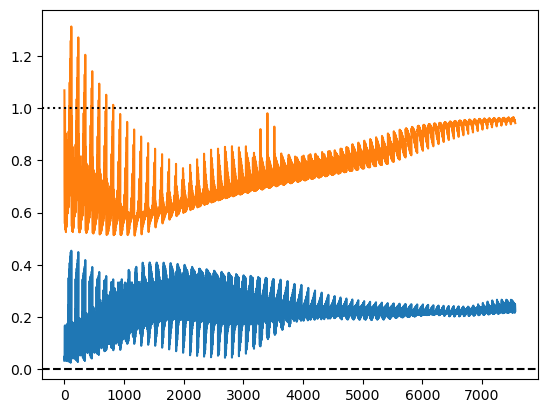

In [16]:
normalized_stellar_models = (stellar_models.T/jnp.median(stellar_models,axis=1)).T * 0.5 # this 0.5 is to make the max more like 1 instead of 2

plt.plot(normalized_stellar_models.min(axis=1))
plt.plot(normalized_stellar_models.max(axis=1))
plt.axhline(0, c='k', linestyle='--')
plt.axhline(1, c='k', linestyle=':')

For stellar parameters, we know the range so we just remap this to 0-1.

In [17]:
spmx = jnp.max(stellar_parameter_arrs, axis=0)
spmi = jnp.min(stellar_parameter_arrs, axis=0)
sprng = spmx - spmi

def rescale_stellar_parameters(sparr):
    """
    sparr is expected to have trailing dimension matching the number of stellar parameters (3 in this case)
    """
    return (sparr - spmi) / sprng

def unscale_stellar_parameters(sparr_scaled):
    """
    sparr_scaled is expected to have trailing dimension matching the number of stellar parameters (3 in this case)
    """
    return sparr_scaled * sprng + spmi

stellar_parameters_rescaled = rescale_stellar_parameters(stellar_parameter_arrs)


It might already be there but just in case put these into the device

In [18]:
normalized_stellar_models = jax.device_put(normalized_stellar_models).block_until_ready()
stellar_parameters_rescaled = jax.device_put(stellar_parameters_rescaled).block_until_ready()
jax_wave = jax.device_put(resampled_wave.to_value(u.angstrom)).block_until_ready()

# Training

Since eval with static params is a lot faster, first try an approach that does one spectrum at a time. Just be sure to randomize the order each time through.

In [38]:
def mse_loss(model, xwl, xsp0, y):
    pred_y = jax.vmap(model, in_axes=(0, None))(xwl, xsp0)
    return jnp.mean((pred_y - y)**2) # MSE loss

@eqx.filter_jit
def make_step(model, opt_state, xwl, xsp0, y):
    loss_value, grads = eqx.filter_value_and_grad(mse_loss)(model, xwl, xsp0, y)
    updates, opt_state = optim.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

  0%|          | 0/75590 [00:00<?, ?it/s]

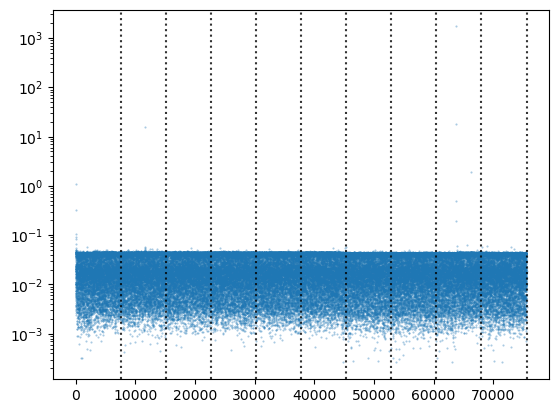

In [77]:
NEPOCHS = 10  # each epoch is over all the spectra
LEARNING_RATE = 1e-3

rkmod, rkepoch = jax.random.split(jax.random.key(42), 2)  # ensures reproducibility below
tpmodel = TransformerPayne(n_stellar_params=3, rkey=rkmod, n_tblocks=4)

optim = optax.adamw(LEARNING_RATE)
opt_state = optim.init(eqx.filter(tpmodel, eqx.is_array))

t = tqdm(total=NEPOCHS*len(normalized_stellar_models))

epoch_boundaries = []
losses = []
for ei in range(NEPOCHS):
    rki, rkepoch = jax.random.split(rkepoch)
    permorder = jax.random.permutation(rki, jnp.arange(len(normalized_stellar_models)))

    for speci in jax.random.permutation(rki, jnp.arange(len(normalized_stellar_models))):
        sflux = normalized_stellar_models[speci]
        sparams = stellar_parameters_rescaled[speci]

        tpmodel, opt_state, loss_value = make_step(tpmodel, opt_state, jax_wave, sparams, sflux)

        t.update()
        t.set_description(f'Epoch {ei+1}/{NEPOCHS}, Logloss: {jnp.log10(loss_value):.4f}')
        losses.append(loss_value)

    epoch_boundaries.append(len(losses))
t.refresh()

plt.semilogy(losses,'.', ms=1, alpha=.4)
for eb in epoch_boundaries:
    plt.axvline(eb, c='k', linestyle=':', alpha=.8)

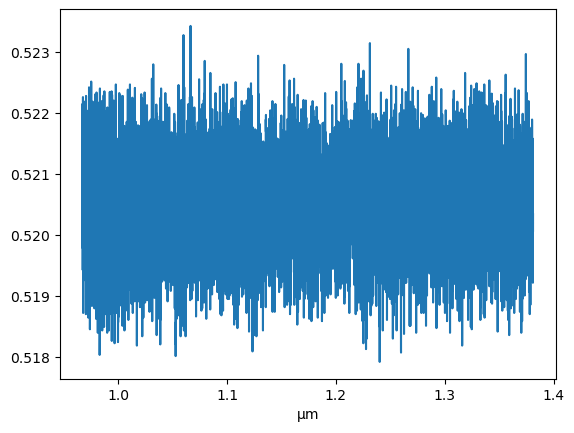

In [78]:
sunlike_pred = jax.vmap(tpmodel, in_axes=(0, None))(jax_wave, stellar_parameters_rescaled[sunlike_idx])
plt.plot(resampled_wave.to(u.micron), sunlike_pred.ravel())

## Bags of pixels

What if we instead train with randomly choosen pixels?

In [21]:
def mse_loss(model, xwl, xsp, y):
    pred_y = jax.vmap(model)(xwl, xsp)
    return jnp.mean((pred_y - y)**2) # MSE loss

@eqx.filter_jit
def make_step(model, opt_state, xwl, xsp, y):
    loss_value, grads = eqx.filter_value_and_grad(mse_loss)(model, xwl, xsp, y)
    updates, opt_state = optim.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

In [22]:
all_wls = jnp.repeat(jax_wave[None,...], len(stellar_parameters_rescaled), axis=0)
stellar_parameter_perpixel = jnp.repeat(stellar_parameters_rescaled[..., None], stellar_models.shape[1], axis=-1).transpose(0, 2, 1)

all_wls = jax.device_put(all_wls).block_until_ready()
stellar_parameter_perpixel = jax.device_put(stellar_parameter_perpixel).block_until_ready()

In [ ]:
N_PIXELS_PER_BATCH = 2**13
NEPOCHS = 2
LEARNING_RATE = 1e-3

nitersperepoch = normalized_stellar_models.size//N_PIXELS_PER_BATCH

print('Required number of iterations per epoch', nitersperepoch, 'for a total number of iterations', nitersperepoch*NEPOCHS)

rkmod, rkepoch = jax.random.split(jax.random.key(42), 2)  # ensures reproducibility below
tpmodel = TransformerPayne(n_stellar_params=3, rkey=rkmod, n_tblocks=4)

optim = optax.adamw(LEARNING_RATE)
opt_state = optim.init(eqx.filter(tpmodel, eqx.is_array))

sfluxs = normalized_stellar_models.reshape(-1)
wls = all_wls.reshape(-1)
sparams = stellar_parameters_rescaled.reshape(-1, 3)

t = tqdm(total=NEPOCHS*nitersperepoch)
losses = []
epoch_boundaries = []
for ei in range(NEPOCHS):
    rki, rkepoch = jax.random.split(rkepoch)
    permorder = jax.random.permutation(rki, jnp.arange(len(wls)))

    for bi in range(len(permorder)//N_PIXELS_PER_BATCH):
        batchidx = permorder[bi*N_PIXELS_PER_BATCH:(bi+1)*N_PIXELS_PER_BATCH]
        bflux = sfluxs[batchidx]
        bwls = wls[batchidx]
        bparams = sparams[batchidx]

        tpmodel, opt_state, loss_value = make_step(tpmodel, opt_state, bwls, bparams, bflux)

        t.update()
        t.set_description(f'Epoch {ei+1}/{NEPOCHS}, Logloss: {jnp.log10(loss_value):.4f}')
        losses.append(loss_value)

    epoch_boundaries.append(len(losses))
    
t.refresh()

plt.semilogy(losses,'.', ms=1, alpha=.4)
for eb in epoch_boundaries:
    plt.axvline(eb, c='k', linestyle=':', alpha=.8)

Required number of iterations per epoch 8253 for a total number of iterations 16506


  0%|          | 0/16506 [00:00<?, ?it/s]

E0827 17:22:40.492279  201092 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0827 17:22:40.648228  201092 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


In [ ]:
sunlike_pred = jax.vmap(tpmodel, in_axes=(0, None))(jax_wave, stellar_parameters_rescaled[sunlike_idx])
plt.plot(resampled_wave.to(u.micron), sunlike_pred.ravel())